In [ ]:
import tempfile
tempdir = tempfile.gettempdir()

#**Random Fuzzy Number Generator**





In [ ]:
#!pip install portion
#import portion as P
from random import random as rm
import math

## Alpha-cut based (for unimodal Fuzzy Numbers)
From "Fuzzy Uncertainty in Random Variable Generation: An a-Cut Approach", by Christian Alfredo Varón-Gaviria, José Luis Barbosa-Fontecha, and Juan Carlos Figueroa-García

In [ ]:
def build_triangular_mf(a, b, c):
  if a > b or b > c:
    raise ValueError("Parameters must form a nondecreasing sequence")
  return lambda x: (x-a)/(b-a) if a <= x < b else (c - x)/(c - b) if b <= x < c else 0

def build_sampleable_triangular_mf(a, b, c):
  if a > b or b > c:
    raise ValueError("Parameters must form a nondecreasing sequence")
  Lambda1 = (b - a) / 2
  Lambda2 = (c - b) / 2
  Lambda = (c - a) / 2

  lambda1 = Lambda1 / Lambda
  lambda2 = Lambda2 / Lambda

  return lambda u1, u2: u1 * (b - a) + a if u2 <= lambda1 else c - u1 * (c - b)


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

In [ ]:
#plt.style.available

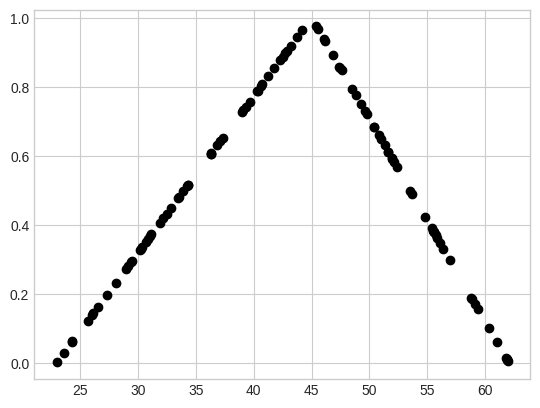

In [ ]:
n = 100

sampler = build_sampleable_triangular_mf(23, 45, 62)
mf = build_triangular_mf(23, 45, 62)
x = [sampler(rm(), rm()) for i in range(n)]
y = [mf(u) for u in x]
plt.plot(x, y, 'o', color='black')

## Cumulative membership function-based
From "Fuzzy Uncertainty in Random Variable Generation: A Cumulative Membership
Function Approach", by Diana Giseth Pulido-L´opez, Mabel García, and Juan Carlos Figueroa-García

In [ ]:
def build_trapezoidal_mf(a, b, c, d):
  if a > b or b > c or c > d:
    raise ValueError("Parameters must form a nondecreasing sequence")
  return lambda x: (x-a)/(b-a) if a <= x < b else 1 if b <= x < c else (d - x)/(d - c) if c <= x < d else 0

def build_sampleable_trapezoidal_mf(a, b, c, d):
  if a > b or b > c or c > d:
    raise ValueError("Parameters must form a nondecreasing sequence")
  Lambda1 = (b - a) / 2
  Lambda2 = c - b
  Lambda3 = (d - c) / 2
  Lambda = (c + d - a - b) / 2

  lambda1 = Lambda1 / Lambda
  lambda2 = Lambda2 / Lambda
  lambda3 = Lambda3 / Lambda

  return lambda u: a + math.sqrt((b - a) * 2 * u * Lambda) if u <= lambda1 else u * Lambda + b - Lambda1 if u <= (lambda1 + lambda2) else d - math.sqrt((d - c)**2 - 2 * (d - c) * (u * Lambda - Lambda1 - Lambda2))


In [ ]:
sampler = build_sampleable_trapezoidal_mf(23, 45, 62, 98)
mf = build_trapezoidal_mf(23, 45, 62, 98)

for j in range(100):
  r = sampler(rm())
  print("({}, {})".format(r, mf(r)))

(43.92861281731409, 0.9513005826051859)
(58.46825152095607, 1)
(53.45804813357552, 1)
(47.848298074366774, 1)
(54.00292539992604, 1)
(63.39284544234775, 0.9613098488236737)
(31.52825657367486, 0.38764802607612997)
(78.78569172566615, 0.5337307853981623)
(86.55663316510787, 0.3178713009692259)
(69.86626388073078, 0.7814926699797005)
(51.2146834843652, 1)
(45.083193893604445, 1)
(62.11042216606745, 0.9969327176092375)
(79.96911791865381, 0.5008578355929498)
(53.09287821128268, 1)
(59.73821556937686, 1)
(59.588732161907814, 1)
(73.24747393178569, 0.6875701685615085)
(54.70603029747501, 1)
(54.618254037793974, 1)
(66.22276244057089, 0.8827010433174753)
(48.98368843016536, 1)
(50.22104506738413, 1)
(66.74974859139229, 0.8680625391279919)
(50.51135727564812, 1)
(51.61243260548472, 1)
(68.45211288635701, 0.8207746420456385)
(37.541994130130554, 0.6609997331877525)
(55.10284621502191, 1)
(66.33612286112614, 0.8795521427464961)
(75.00626587099752, 0.6387148369167355)
(62.77080783821596, 0.97858

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

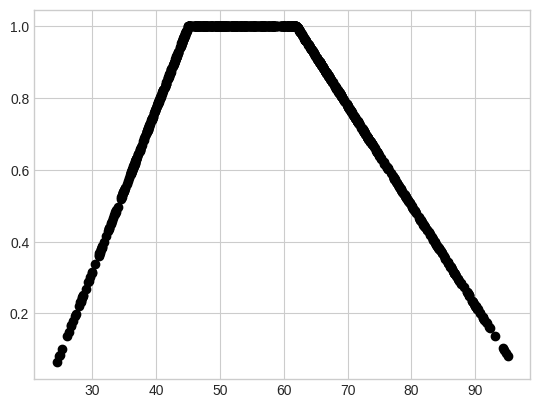

In [ ]:
n = 1000
x = [sampler(rm()) for i in range(n)]
y = [mf(u) for u in x]
plt.plot(x, y, 'o', color='black')

#**Simulación de una instancia de VRP utilizando Simpy**

Características:

*   1 vehiculo con límite de capacidad.
*   1 depósito (inicio y fin del recorrido).
*   N clientes.
*   Se posee una estimación de las demandas de los clientes y del tiempo de recorrido entre cada uno de ellos incluído el depósito.
*   La simulación finaliza al regresar al depósito.





## Instalación e importación de librerías necesarias

In [ ]:
!pip install simpy
!pip install pandas

In [ ]:
import simpy
import random
import numpy as np
import pandas as pd

## Definicion e inicializacion de estructuras de datos



### Samplers for Random Fuzzy Number Generator

In [ ]:
sampler_triangular = build_sampleable_triangular_mf(0.3, 0.7, 3.0)
sampler_trapezoidal_prod_pedido = build_sampleable_trapezoidal_mf(30, 45, 55, 75)
sampler_trapezoidal_prod_estimado = build_sampleable_trapezoidal_mf(30, 35, 50, 60)

In [ ]:
sampler_trapezoidal_prod_estimado(rm())
#sampler_triangular(rm(),rm())

44.30089453466804

###Tabla de distancias/tiempos estimados entre los clientes, incluyendo el deposito

In [ ]:
# Importar matriz de adyacencia desde csv
#df = pd.read_csv('VRP-data - 2.csv',sep=";")
#df.index = df.columns
#df

In [ ]:
ubicaciones = ['Frigorifico Tres Arroyos', 'La Blanq y D Gaspar', 'D Gaspar y La Blanquita', 'Rougier Carnes', 'La Pulperia',
       'Granja de Rosso', 'La Estancia', 'El Buen Trato', 'El Ternero Gasolero', 'La Imbatible', 'El tropezon',
       'Estancia La Argentina', 'La Providencia', 'Don Miguel', 'El Gauchito', 'Del Campo Carnes', 'El mejor corte',
       'Lo de gaston Araoz', 'Lo de gaston ruta', 'La Campeira', 'Don Adolfo']

tiempos = np.array([[ 0,  9,  6,  4,  4,  7,  9, 10, 12, 10,  8, 10, 10, 12, 12, 12,
         6,  7,  6,  9, 12],
       [ 8,  0,  5,  8,  8,  9,  9, 10, 11,  9,  9, 12, 12, 11, 13, 14,
         5, 10,  6, 16, 14],
       [ 6,  6,  0,  5,  5,  5,  5,  8,  7,  5,  7,  6,  7,  7,  8,  9,
         2,  6,  3, 10,  8],
       [ 4,  8,  5,  0,  1,  4,  5,  5,  7,  6,  8,  5,  7,  8,  3,  5,
         5,  6,  7, 12,  7],
       [ 5,  9,  6,  3,  0,  5,  7,  6,  8,  7,  6,  9,  9, 10, 10, 10,
         6,  6,  6,  7, 10],
       [ 7,  9,  6,  5,  5,  0,  4,  3,  5,  4,  3,  5,  5,  5,  6,  7,
         6,  1,  6,  7,  6],
       [ 8,  9,  5,  6,  5,  2,  0,  5,  4,  2,  4,  3,  4,  4,  5,  7,
         5,  3,  6,  8,  4],
       [ 9, 12,  9,  7,  6,  5,  6,  0,  5,  7,  3,  7,  5,  5,  8,  8,
        10,  5, 10,  4,  6],
       [10, 11,  7,  8,  7,  5,  4,  3,  0,  4,  4,  3,  2,  1,  4,  4,
         8,  5,  9,  6,  3],
       [ 9,  9,  6,  7,  6,  5,  3,  7,  6,  0,  6,  3,  5,  5,  3,  5,
         5,  5,  7, 10,  4],
       [ 7, 10,  6,  7,  4,  2,  4,  3,  5,  5,  0,  5,  5,  5,  7,  8,
         7,  2,  7,  6,  6],
       [ 9, 12,  6,  3,  6,  4,  2,  8,  4,  1,  5,  0,  4,  6,  3,  4,
         6,  4,  7, 10,  3],
       [ 9, 12,  7,  6,  6,  4,  4,  4,  3,  4,  3,  4,  0,  2,  5,  5,
         8,  4,  8,  7,  4],
       [10, 13,  9,  8,  7,  5,  6,  2,  4,  6,  4,  5,  3,  0,  6,  6,
        10,  5, 10,  6,  5],
       [12, 13,  8,  5,  9,  6,  5,  7,  5,  3,  6,  3,  5,  5,  0,  2,
         9,  7,  9,  8,  3],
       [12, 14,  8,  5,  9,  6,  4,  5,  4,  3,  6,  3,  4,  4,  4,  0,
         8,  7,  9,  8,  2],
       [ 6,  5,  2,  5,  6,  7,  5,  9,  8,  7,  8,  7,  8,  8,  9, 10,
         0,  7,  2, 12,  9],
       [ 6,  8,  5,  5,  4,  1,  3,  4,  5,  4,  3,  4,  5,  5,  6,  7,
         6,  0,  5,  6,  6],
       [ 7,  3,  4,  8,  8,  8,  9, 12, 12, 10, 10,  9,  9, 10, 10, 12,
         4,  8,  0, 12, 10],
       [ 9, 14, 10, 10,  6,  6,  8,  4,  5,  8,  6,  8,  6,  6,  9,  8,
        12,  7, 12,  0,  7],
       [12, 14,  8,  5,  9,  6,  4,  6,  3,  3,  7,  3,  5,  4,  4,  3,
         8,  7, 10,  7,  0]])
df_tiempos = pd.DataFrame(tiempos, columns=ubicaciones, index=ubicaciones)
df_tiempos

,Frigorifico Tres Arroyos,La Blanq y D Gaspar,D Gaspar y La Blanquita,Rougier Carnes,La Pulperia,Granja de Rosso,La Estancia,El Buen Trato,El Ternero Gasolero,La Imbatible,...,Estancia La Argentina,La Providencia,Don Miguel,El Gauchito,Del Campo Carnes,El mejor corte,Lo de gaston Araoz,Lo de gaston ruta,La Campeira,Don Adolfo
Frigorifico Tres Arroyos,0,9,6,4,4,7,9,10,12,10,...,10,10,12,12,12,6,7,6,9,12
La Blanq y D Gaspar,8,0,5,8,8,9,9,10,11,9,...,12,12,11,13,14,5,10,6,16,14
D Gaspar y La Blanquita,6,6,0,5,5,5,5,8,7,5,...,6,7,7,8,9,2,6,3,10,8
Rougier Carnes,4,8,5,0,1,4,5,5,7,6,...,5,7,8,3,5,5,6,7,12,7
La Pulperia,5,9,6,3,0,5,7,6,8,7,...,9,9,10,10,10,6,6,6,7,10
Granja de Rosso,7,9,6,5,5,0,4,3,5,4,...,5,5,5,6,7,6,1,6,7,6
La Estancia,8,9,5,6,5,2,0,5,4,2,...,3,4,4,5,7,5,3,6,8,4
El Buen Trato,9,12,9,7,6,5,6,0,5,7,...,7,5,5,8,8,10,5,10,4,6
El Ternero Gasolero,10,11,7,8,7,5,4,3,0,4,...,3,2,1,4,4,8,5,9,6,3
La Imbatible,9,9,6,7,6,5,3,7,6,0,...,3,5,5,3,5,5,5,7,10,4


### Tabla de Planificacion inicial de orden de visita, con estimacion de cantidad de productos requeridos

In [ ]:
#Uncertainty:
############[1: low, 2: medium, 3: high]
def estimar(clientes, uncertainty=1):
  estimaciones = np.empty((0, 4), dtype=int)
  for i in clientes[1:len(clientes)]:
    delta= 0 #int(random.uniform(0,20))
    if uncertainty==3:
      a = int(random.uniform(30,33)) + delta
      b = int(random.uniform(43,55)) + delta
      c = int(random.uniform(56,62)) + delta
      d = int(random.uniform(77,83)) + delta
    elif uncertainty==2:
      a = int(random.uniform(35,40)) + delta
      b = int(random.uniform(45,55)) + delta
      c = int(random.uniform(56,60)) + delta
      d = int(random.uniform(65,70)) + delta
    else:
      a = int(random.uniform(45,48)) + delta
      b = int(random.uniform(49,53)) + delta
      c = int(random.uniform(54,58)) + delta
      d = int(random.uniform(59,61)) + delta
    estimaciones = np.append(estimaciones, np.array([[a,b,c,d]]), axis=0)
  return estimaciones

In [ ]:
#Uncertainty:
############[1: low, 2: medium, 3: high]
def planificacion(clientes, uncertainty=1):
  data_plan = np.empty((0, 10))
  estimaciones = estimar(clientes,uncertainty)
  n=1
  for i in clientes[1:len(clientes)]:
    sampler_trapezoidal = build_sampleable_trapezoidal_mf(estimaciones[n-1][0], estimaciones[n-1][1], estimaciones[n-1][2], estimaciones[n-1][3])
    estimado = int(sampler_trapezoidal(rm()))
    pedido = int(sampler_trapezoidal(rm())) #int(random.uniform(0.8,1.2)*estimado)
    data_plan = np.append(data_plan, np.array([[i,n, estimaciones[n-1][0], estimaciones[n-1][1], estimaciones[n-1][2], estimaciones[n-1][3], estimado, 0 ,pedido,0]]), axis=0)
    n=n+1
  plan = pd.DataFrame(data_plan, columns=['cliente','idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados','productosPedidosConocido','productosPedidos','productosRecibidos'])
  return plan

In [ ]:
planificacion(ubicaciones)

,cliente,idCliente,estimacionA,estimacionB,estimacionC,estimacionD,productosEstimados,productosPedidosConocido,productosPedidos,productosRecibidos
0,La Blanq y D Gaspar,1,45,50,54,59,46,0,49,0
1,D Gaspar y La Blanquita,2,46,52,56,59,47,0,53,0
2,Rougier Carnes,3,46,49,57,60,51,0,50,0
3,La Pulperia,4,46,51,56,60,51,0,50,0
4,Granja de Rosso,5,46,52,56,59,58,0,52,0
5,La Estancia,6,47,49,55,60,57,0,58,0
6,El Buen Trato,7,46,51,56,60,50,0,53,0
7,El Ternero Gasolero,8,45,51,56,59,47,0,55,0
8,La Imbatible,9,47,49,55,60,48,0,47,0
9,El tropezon,10,45,49,55,60,54,0,53,0


In [ ]:
planif = planificacion(ubicaciones)

satisfied_customers =  (planif[planif.productosPedidos == planif.productosRecibidos].shape[0])/ planif.shape[0]

prueba = (planif[planif.productosPedidosConocido == planif.productosRecibidos].shape[0])/ planif.shape[0]

prueba

1.0

### Tabla de "registro de viaje"

*   Orden de visita real
*   Confirmacion de atencion
*   Duracion del viaje
*   Tiempos de llegada
*   Tiempo de atencion
*   Cantidad de pedido real (en el momento)
*   Cantidad de productos realmente entregados

In [ ]:
#data_viaje = np.array([0,0,0,0,0,0,0,0]) # se cargaria durante la simulacion
df_viaje =  pd.DataFrame( columns=['Cliente','orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'])
df_viaje

,Cliente,orden_visita_real,duracion_viaje,tiempo_llegada,duracion_espera,posponer,tiempo_atencion,pedido,duracion_atencion,entregar,entregado


## Implementación de la clase 'Vehicle'

Esta clase define e implementa la lógica de la simulación.
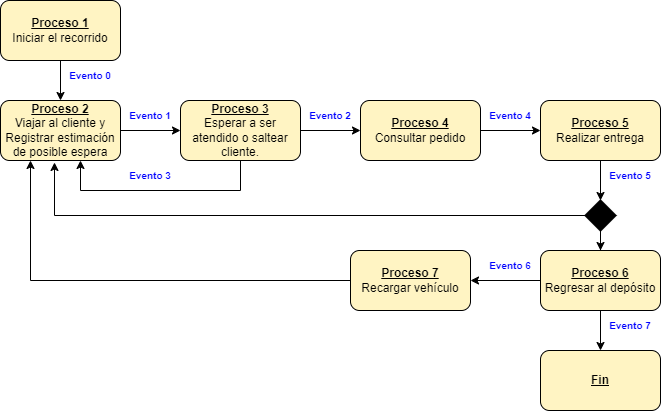

In [ ]:
class Vehicle(object):
    def __init__(self, env, capacity, available_products, times_map, planning, warehouse, max_time=360):
        self.env = env
        #self.vehicle = simpy.Resource(env, num_vehicles)
        self.available_products = available_products
        self.capacity = capacity
        self.travel_time = 0
        self.times_map_base = times_map.copy()
        self.current_times_map = self.times_map_base.copy()
        self.time_block = 0 # sin actualizacion de tiempos   #1
        self.planning = planning.copy()
        self.planning = self.planning.sort_values('idCliente')
        self.trip_log = pd.DataFrame( columns=['Cliente', 'idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'])
        self.warehouse = warehouse
        self.current_location = warehouse
        self.customers_visited = 0
        self.current_event= ''
        self.current_time=''
        self.current_customerId = None
        self.cancel = 0
        self.endTour = 0
        self.next_customer = 1
        self.max_time = max_time
        self.sampler_unloading_time = build_sampleable_triangular_mf(5, 6, 7)

    def set_next_customer(self, id_customer):
        self.next_customer = id_customer

    def update_current_time_map(self,a,b):
      #times_change = np.random.uniform(0.8,1.7,len(self.times_map_base.to_numpy()[0]))
      times_change = np.random.uniform(a,b,len(self.times_map_base.to_numpy()[0]))
      self.current_times_map = times_change * self.times_map_base.copy()

    def run (self,env):
        initial_time = self.env.now
        total_travel_time = self.env.now - initial_time
        self.current_event = 0 #'inicio'

        #realizar el recorrido visitando los clientes (mientras no se supere el tiempo maximo o no se haya concluido el trabajo)
        trip_number=0
        while (self.endTour!=1 and total_travel_time<self.max_time):
          # Actualización de tiempos de viaje
          # self.time_block sirve para que la actualización se realice solo la primera vez que la simulación entra al rango de tiempo.
          if (total_travel_time in range(90,180) and self.time_block==1):
            self.update_current_time_map(0.8,1.2)
            self.time_block = 2
          elif (total_travel_time in range(150,270) and self.time_block==2):
            self.update_current_time_map(1.4,2)
            self.time_block = 3
          elif (total_travel_time in range(270,360) and self.time_block==3):
            self.update_current_time_map(0.9,1.2)
            self.time_block = 4

          self.cancel = 0
          trip_number += 1
          #print("Tiempo act: ",total_travel_time,"  Cliente= ", self.next_customer," Mercaderia: ",self.available_products)

          if (self.next_customer==0 or self.available_products==0):
            #volver al deposito a recargar productos
            #print(self.current_location)
            trip_duration = self.current_times_map.loc[self.current_location].loc[self.warehouse] #tiempo de viaje desde la ubicacion actual al deposito
            #Si se viaja al deposito y ya esta en el deposito, se toma como una espera/ descanso y se adelanta 15 minutos la simulación.
            if (trip_duration ==0):
              trip_duration = 15
            #print("tiempo de viaje al deposito: ", trip_duration)

            yield self.env.timeout(trip_duration)
            self.current_event = 6 #'recargar'
            self.available_products = self.capacity
            recharge_time = int(self.capacity * self.sampler_unloading_time(rm(),rm()) / 60 /2)

            yield self.env.timeout(recharge_time)
            # Crear el registro en trip_log
            self.customers_visited = self.customers_visited + 1
            #'Cliente','idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'
            self.trip_log.loc[self.customers_visited] = (self.warehouse, 0, self.customers_visited, trip_duration, self.env.now, 0,0,recharge_time,0,0,0,0)

            self.current_location = self.warehouse
            self.current_time= self.env.now

          else:
            self.current_customerId = self.next_customer
            customer= self.planning.sort_index().at[self.current_customerId -1,"cliente"]

            yield self.env.process(self.travel_next_customer(customer))

            #En esta version no se considera la espera
            #yield self.env.process(self.wait_customer(customer))
            if (self.cancel == 0):
              yield self.env.process(self.check_order(customer))
              yield self.env.process(self.deliver_products(customer))


          total_travel_time = self.env.now - initial_time
          #yield self.env.timeout(1)

          pedido = self.planning['productosPedidos'].to_numpy(dtype=int)
          entregado = self.planning['productosRecibidos'].to_numpy(dtype=int)
          if(sum(pedido-entregado)==0): #SI TODOS LOS CLIENTES FUERON SATISFECHOS
            self.endTour=1

        #volver al deposito
        trip_duration = self.current_times_map.loc[self.current_location].loc[self.warehouse] #tiempo de viaje desde la ubicacion actual al deposito
        yield self.env.timeout(trip_duration)
        # Crear el registro en trip_log
        self.customers_visited = self.customers_visited + 1
        #'Cliente','idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'
        self.trip_log.loc[self.customers_visited] = (self.warehouse, 0, self.customers_visited, trip_duration, self.env.now, 0,0,0,0,0,0,0)
        self.current_event = 7 #'fin'
        self.current_location = self.warehouse

        total_travel_time = self.env.now - initial_time
        #print(self.planning.sort_index().to_string()) #.sort_index()
        #print(self.trip_log.to_string())
        #print("Tiempo total de viaje: ",total_travel_time)

    def travel_next_customer(self, customer):
        initial_travel_time = self.env.now
        #print('Viajando a %s' % customer)

        # Generar el tiempo de viaje desde la ubicacion actual al proximo cliente.
        travel_time = self.current_times_map.loc[self.current_location].loc[customer]

        #Si se viaja al mismo cliente en el que se está, se toma como una espera/ descanso y se adelanta 10 minutos la simulación.
        if (travel_time ==0):
          travel_time = 10
          #self.cancel = 1

        yield self.env.timeout(travel_time)

        #print('Arribo a %s' % customer)

        self.customers_visited = self.customers_visited + 1
        self.current_event = 1 # ('travel-'+str(self.customers_visited+1))

        # Geenrar estimacion de espera / En esta version no se considera la espera
        #wait_estimated = random.uniform(1,5)  # Revisar distribucion
        wait_estimated = 0

        # Crear el registro en trip_log
        #'Cliente','idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'
        self.trip_log.loc[self.customers_visited] = (customer, self.current_customerId, self.customers_visited, travel_time, self.env.now, wait_estimated,0,0,0,0,0,0)

        #Actualizar la ubicacion y la hora actual
        self.current_location = customer
        self.current_time= self.env.now

    def wait_customer(self, customer):   # ver como modificarlo para que pueda haber una consulta/decision
        if (self.trip_log.at[self.customers_visited, 'posponer'] == 0):
          yield self.env.timeout(self.trip_log.at[self.customers_visited, 'duracion_espera'])
          self.current_event = 2 #'wait-'+str(self.customers_visited)
        else:
          self.cancel == 1
          self.current_event = 3 #'salteado-'+str(self.customers_visited)
        self.current_time= self.env.now

    def check_order(self, customer):
        #print('Consultando pedido en %s' % customer)

        #actualizamos productosPedidosConocido
        self.planning.at[self.current_customerId-1,"productosPedidosConocido"] = self.planning.at[self.current_customerId-1,"productosPedidos"]

        pedido_inicial = int(self.planning.sort_index().at[self.current_customerId -1,"productosPedidos"])
        recibido_actual = int(self.planning.sort_index().at[self.current_customerId -1,"productosRecibidos"])
        pedir = pedido_inicial - recibido_actual

        self.trip_log.at[self.customers_visited, 'pedido'] = pedir

        yield self.env.timeout(1/60)

        self.current_event = 4 #'check_order-'+str(self.customers_visited)

        self.current_time= self.env.now


    def deliver_products(self, customer):
        # Entregar productos, registrar y actualizar variables
        entregar = int(self.trip_log.at[self.customers_visited, 'entregar'])
        if (entregar>self.available_products):
          entregar = self.available_products

        deliver_time = int(entregar * self.sampler_unloading_time(rm(),rm()) / 60)

        self.available_products = self.available_products - entregar
        self.trip_log.at[self.customers_visited, 'duracion_atencion'] = deliver_time
        self.trip_log.at[self.customers_visited, 'entregado'] = entregar

        recibido_ant = int(self.planning.sort_index().at[self.current_customerId -1,'productosRecibidos'])
        recibido = recibido_ant + entregar

        self.planning = self.planning.sort_index()
        self.planning.at[self.current_customerId-1,'productosRecibidos'] = recibido

        yield self.env.timeout(abs(deliver_time))

        self.current_event = 5  #'deliver_products-'+str(self.customers_visited)
        self.current_time= self.env.now


## Pruebas de la simulación

In [ ]:
df_planificacion = planificacion(ubicaciones)

capacity_vehicle_1 = 400
available_products_vehicle_1 = 350
warehouse_vehicle_1 = ubicaciones[0] #la primer ubicacion se toma como el depósito
current_time=''
current_event= ''
current_location = warehouse_vehicle_1


In [ ]:
env = simpy.Environment()
vehicle_1 = Vehicle(env, capacity_vehicle_1, available_products_vehicle_1, df_tiempos, df_planificacion, warehouse_vehicle_1)
env.process(vehicle_1.run(env))
#env.run(until=140)
env.step()
event = new_event= vehicle_1.current_event
print(event)
print(env.peek())
print(env.step())

0
0
None


In [ ]:
#print(vehicle_1.planning.sort_index())
print(vehicle_1.planning)


                    cliente idCliente estimacionA estimacionB estimacionC  \
0       La Blanq y D Gaspar         1          45          49          54   
9               El tropezon        10          47          51          56   
10    Estancia La Argentina        11          45          50          54   
11           La Providencia        12          45          49          54   
12               Don Miguel        13          46          49          56   
13              El Gauchito        14          45          52          54   
14         Del Campo Carnes        15          47          49          55   
15           El mejor corte        16          45          51          55   
16       Lo de gaston Araoz        17          46          52          57   
17        Lo de gaston ruta        18          46          50          54   
18              La Campeira        19          46          51          54   
1   D Gaspar y La Blanquita         2          45          49          54   

In [ ]:
until = 50
while (event == new_event) and (env.peek() < until): # "env.peek() < until" controla que no haya llegado al fin la ejecucion (peek da el tiempo del proximo evento)
     env.step()
     new_event= vehicle_1.current_event
    #event = vehicle_1.current_event
event = new_event
print(event)
print('tiempo actual:')
print(vehicle_1.current_time)


1
tiempo actual:
9


In [ ]:
vehicle_1.current_event
vehicle_1.customers_visited


1

In [ ]:
vehicle_1.trip_log

,Cliente,idCliente,orden_visita_real,duracion_viaje,tiempo_llegada,duracion_espera,posponer,tiempo_atencion,pedido,duracion_atencion,entregar,entregado
1,La Blanq y D Gaspar,1,1,9,9,0,0,0,0,0,0,0


______________________________
# **Ensamble en un Python Environment de TF-Agents**

Ensamble de la simulación de la instancia VRP en un Python Environment de TF-Agents

## Instalación e importación de librerías necesarias

In [ ]:
#!pip install --upgrade pip
#!pip install --upgrade tensorflow
#!pip install tensorflow[and-cuda]==2.15.0
#!pip install tensorflow[and-cuda]
#!pip install tensorflow==2.15.0
#!pip install tf-agents

# Newer versions of tensorflow-probability require newer versions of TensorFlow.
#!pip install tensorflow-probability==0.8.0
#!pip install tf-agents==0.19.0

!pip install tf-keras
!pip install tf-agents[reverb]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully uninstalled tensorboard-2.15.2
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.15.1
    Uninstalling tensorflow-2.15.1:
      Successfully uninstalled tensorflow-2.15.1
  Using cached tensorflow-2.15.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow-2.1

In [ ]:
#!pip install --upgrade tensorflow-probability

In [ ]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import abc
import tensorflow as tf
#import numpy as np
#import tf_agents

from tf_agents.environments import py_environment
from tf_agents.environments import tf_environment
from tf_agents.environments import tf_py_environment
from tf_agents.environments import utils
from tf_agents.specs import array_spec
#from tf_agents.environments import wrappers
#from tf_agents.environments import suite_gym
from tf_agents.trajectories import time_step as ts
from tf_agents.trajectories.time_step import StepType
from tf_agents.trajectories.time_step import TimeStep



## Implementación de la clase 'VRPEnv'

Esta clase implementa un entorno para aprendizaje por refuerzo utilizando la API de PyEnvironment de la librería TF-Agents.
Si RL = False, el entorno adapta las observaciones para un Agente basado en optimización por colonia de hormigas.
Si RL = True, el entorno adapta las observaciones para un Agente basado en Aprendizaje por Refuerzo (RL).



Este entorno implementa un problema VRP de entrega de mercadería.
El objetivo es que el agente entrene una política que controlará el vehículo para que visite a los clientes y entregue la mercadería, buscando minimizar el tiempo de recorrido y maximizar la satisfacción de los clentes (cumplir con la demanda). El vehículo tiene una restricción de capacidad y un tiempo esperado de viaje.

En cada episodio el vehículo parte del depósito y finaliza el recorrido al regresar al mismo. El retorno será **( ..... completar)**

## Probar el entorno

In [ ]:
class VRPEnv(py_environment.PyEnvironment):

  def update_valid_actions(self):
    self.valid_actions = np.zeros((1,self.actions), dtype= np.int32)

    #REVISAR ESTO
    self.valid_actions[0][2:4]=1  # 3 acciones de entrega validas

    if (self.vehicle.available_products<30): #REVISAR ESTO
        self.valid_actions[0][self.customers+1:self.customers+2]= 1 #siempre se puede viajar al deposito

    """
    a = np.array([], dtype= np.int32)
    for ind in self.vehicle.planning.set_index('idCliente').index:
          if (int(self.vehicle.planning.set_index('idCliente')['productosPedidos'][ind]) - int(self.vehicle.planning.set_index('idCliente')['productosRecibidos'][ind]) <=0):
            a = np.append(a, 0)
          else:
            a = np.append(a, 1)
    """
    #print(self.vehicle.planning.sort_index())
    Estimado =  self.vehicle.planning.sort_index()['productosEstimados'].to_numpy(dtype=int)
    PedidoConocido = self.vehicle.planning.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
    Recibido = self.vehicle.planning.sort_index()['productosRecibidos'].to_numpy(dtype=int)
    self.demandas = np.where(PedidoConocido==0,Estimado,PedidoConocido) - Recibido

    active_customers = np.where(self.demandas>0,np.ones(self.customers, dtype= np.int32),np.zeros(self.customers, dtype= np.int32))
    #print("active customers: ", active_customers)
    self.valid_actions[0][self.customers+2:self.actions]= active_customers #a #clientes que todavía no estan satisfechos
    #print("Valid Actions: ", self.valid_actions[0])


  def update_metrics(self):
    #pedido = self.vehicle.trip_log['pedido'].to_numpy(dtype=int)
    #entregado = self.vehicle.trip_log['entregado'].to_numpy(dtype=int)

    # Final Environment reward (ya se va autosumando en el desarrollo)
    ##

    # Percentage of satisfied customers
    #self.satisfied_customers =  (self.vehicle.planning[self.vehicle.planning.productosPedidosConocido == self.vehicle.planning.productosRecibidos].shape[0]) #/ self.vehicle.planning.shape[0] *100
    Estimado =  self.vehicle.planning.sort_index()['productosEstimados'].to_numpy(dtype=int)
    PedidoConocido = self.vehicle.planning.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
    Recibido = self.vehicle.planning.sort_index()['productosRecibidos'].to_numpy(dtype=int)
    self.demandas = np.where(PedidoConocido==0,Estimado,PedidoConocido) - Recibido
    self.satisfied_customers = (self.customers - np.count_nonzero(self.demandas)) # /self.customers *100

    # Percentage of customers without deliveries
    #self.customers_without_deliveries = (self.vehicle.planning[self.vehicle.planning.productosRecibidos == 0].shape[0]) #/ self.vehicle.planning.shape[0] *100

    self.customers_without_deliveries = (self.customers - np.count_nonzero(Recibido)) #/self.customers *100



    # Total time
    self.total_time = self.vehicle.current_time
    # Final satisfaction without discounts
    self.total_satisfaction = sum(Recibido)/sum(np.where(PedidoConocido==0,Estimado,PedidoConocido)) # * 100

    # Number of visits to the warehouse
    self.wharehouse_visits = self.vehicle.trip_log[self.vehicle.trip_log.Cliente == self.warehouse_vehicle].shape[0]
    # Number of trips
    self.trips = len(self.vehicle.trip_log)


  def get_metrics(self):
    metrics = dict(Total_reward = self.total_reward,
                   Satisfied_customers = self.satisfied_customers,
                   Customers_without_deliveries = self.customers_without_deliveries,
                   Total_time = self.total_time,
                   Total_satisfaction = self.total_satisfaction,
                   Wharehouse_visits = self.wharehouse_visits,
                   Trips = self.trips)

    return metrics

   #Uncertainty:
   ############[1: low, 2: medium, 3: high]
  def __init__(self, ubicaciones, max_time=480, elapsed_time_discount=0.9, RL=True, dinamic_times=False, uncertainty=1):
    self.ubicaciones = ubicaciones
    self.RL = RL
    self.dinamic_times =dinamic_times
    self.uncertainty = uncertainty

    self.planning = planificacion(self.ubicaciones,self.uncertainty)
    self.max_time = max_time
    #elapsed time discount parameter
    self.elapsed_time_discount = elapsed_time_discount
    self.customers = len(self.planning.index)


    self.capacity_vehicle = 400
    self.available_products_vehicle = 350
    self.warehouse_vehicle = self.ubicaciones[0]

    ##METRICS
    # Final Environment reward
    self.total_reward = 0
    # Percentage of satisfied customers
    self.satisfied_customers = 0
    # Percentage of customers without deliveries
    self.customers_without_deliveries = 0
    # Total time
    self.total_time = 0
    # Final satisfaction without discounts
    self.total_satisfaction = 0
    # Number of visits to the warehouse
    self.wharehouse_visits = 0
    # Number of trips
    self.trips = 0

    self.env = simpy.Environment()
    self.vehicle = Vehicle(self.env, self.capacity_vehicle, self.available_products_vehicle, df_tiempos, self.planning, self.warehouse_vehicle, self.max_time)

    if(self.dinamic_times): self.vehicle.time_block = 1
    if(self.uncertainty==3): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 8, 11)
    elif(self.uncertainty==2): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 7, 8)

    self.actions = 2*(self.customers+1)
    self.update_valid_actions()

    #Componentes de la acción/decisión:
    #1- Define la cantidad de productos a entregar a un cliente.
        # Cambiar a Opciones: 0:no entregar; 1:entregar la mitad de lo pedido; 2:entregar solo lo estimado;  3:entregar lo solicitado
    #2- Define el proximo destino
    """ self._action_spec = array_spec.BoundedArraySpec(
        shape=(2,), dtype=np.int32, minimum=[0,0], maximum=[2,self.customers], name='action') """

    self._action_spec = array_spec.BoundedArraySpec(
        shape=(2,), dtype=np.int32, minimum=[0,0], maximum=[self.customers,self.customers], name='action')


    self.valid_action_spec = array_spec.BoundedArraySpec(
        shape=(1,self.actions), dtype=np.int32, minimum=0, maximum=1, name='valid_actions') ## Tiene que ser un vector plano o tienen que ser uno por cada accion ????

    #Datos que ve el agente en cada paso:
    #1- Evento:
        #0: Inicio del recorrido
        #1: llegada al cliente
        #2: termina espera y es atendido
        #3: cliente salteado (indica cómo reorganiza??)
        #4: pedido registrado
        #5: entrega realizada
        #6: recarga en deposito
        #7: Fin del reccorrido
    #2- Número del Cliente actual
    #3- Tiempo actual
    #4- Mercadería disponible
    #5- Pedido del cliente (si corresponde, sino 0)
    #6- Estimado (Estimado inicial - recibido actual)

    #OBSERVACION BASE
    general_obs_spec= array_spec.BoundedArraySpec(
        shape=(6,), dtype=np.int32, minimum=0, name='general')

    #OBSERVACIÓN PLAN
    planificacion_obs_spec= array_spec.BoundedArraySpec(
        shape=(len(self.ubicaciones)-1,8), dtype=np.int32, minimum=0, name='plan')

    #OBSERVACIÓN MATRIZ TIEMPOS
    tiempos_obs_spec= array_spec.BoundedArraySpec(
        shape=(len(self.ubicaciones),len(self.ubicaciones)), dtype=np.int32, minimum=0, name='tiempos')

    #OBSERVACIÓN COMPLETA
    self._observation_spec = {
        'general': general_obs_spec,
        'plan': planificacion_obs_spec,
        'tiempos': tiempos_obs_spec
        }

    if (RL==True):
      self._observation_spec = {'observation': self._observation_spec,
                                'valid_actions': self.valid_action_spec}

    self._state = {
        'general': np.array([0,0,0,self.vehicle.available_products,0,0], dtype=np.int32),
        'plan': self.vehicle.planning[['idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados','productosPedidosConocido','productosRecibidos']].to_numpy(dtype=np.int32), #np.int32
        'tiempos': self.vehicle.current_times_map.to_numpy(dtype=np.int32)
        }

    if (self.RL==True):
      self._state = {'observation': self._state,
                     'valid_actions': self.valid_actions}  ## SETEAR LAS ACCIONES VALIDAS = 1 e INVALIDAS = 0

    #self._state = [0,0,self.vehicle.available_products,0]
    self._episode_ended = False
    self.old_event = self.event = self.new_event= None

  def action_spec(self):
    return self._action_spec

  def observation_spec(self):
    return self._observation_spec

  def reward_spec(self):
    """Defines the rewards that are returned by `step()`.
    Override this method to define an environment that uses non-standard reward
    values, for example an environment with array-valued rewards.
    Returns:
      An `ArraySpec`, or a nested dict, list or tuple of `ArraySpec`s.
    """
    return array_spec.ArraySpec(shape=(), dtype=np.float32, name='reward')

  def time_step_spec(self) -> ts.TimeStep:
    """Describes the `TimeStep` fields returned by `step()`.
    Override this method to define an environment that uses non-standard values
    for any of the items returned by `step()`. For example, an environment with
    array-valued rewards.
    Returns:
      A `TimeStep` namedtuple containing (possibly nested) `ArraySpec`s defining
      the step_type, reward, discount, and observation structure.
    """
    return ts.time_step_spec(self.observation_spec(), self.reward_spec())


  def _reset(self):
    # Resetea la simulacion y ejecuta el paso inicial
    self.env = simpy.Environment()
    self.planning = planificacion(self.ubicaciones,self.uncertainty)
    self.update_valid_actions()

    self.vehicle = Vehicle(self.env, self.capacity_vehicle, self.available_products_vehicle, df_tiempos, self.planning, self.warehouse_vehicle, self.max_time)

    if(self.dinamic_times): self.vehicle.time_block = 1
    if(self.uncertainty==3): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 8, 11)
    elif(self.uncertainty==2): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 7, 8)

    self.env.process(self.vehicle.run(self.env))
    self.env.step()
    self.event = self.new_event = self.vehicle.current_event

    ##METRICS
    # Final Environment reward
    self.total_reward = 0
    # Percentage of satisfied customers
    self.satisfied_customers = 0
    # Percentage of customers without deliveries
    self.customers_without_deliveries = 0
    # Total time
    self.total_time = 0
    # Final satisfaction without discounts
    self.total_satisfaction = 0
    # Number of visits to the warehouse
    self.wharehouse_visits = 0
    # Number of trips
    self.trips = 0

    # Actualiza el estado y devuelve la observacion inicial
    self._state = {
        'general': np.array([0,0,0,self.vehicle.available_products,0,0], dtype=np.int32),
        'plan': self.vehicle.planning[['idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados','productosPedidosConocido','productosRecibidos']].to_numpy(dtype=np.int32),
        'tiempos': self.vehicle.current_times_map.to_numpy(dtype=np.int32)
        }

    if (self.RL==True):
      self._state = {'observation': self._state,
                     'valid_actions': self.valid_actions}  ## SETEAR LAS ACCIONES VALIDAS = 1 e INVALIDAS = 0

    self._episode_ended = False

    return TimeStep(StepType.FIRST, reward=np.array(0.0,dtype=np.float32),  discount=np.array(0.0,dtype=np.float32), observation=self._state)
    #return ts.restart(self._state,reward_spec=array_spec.ArraySpec(shape=(), dtype=np.float32))
    #return ts.restart(np.array(self._state, dtype=np.float32),reward_spec=array_spec.ArraySpec(shape=(), dtype=np.float32))


  def _step(self, action):

    action = tf.cast(action, tf.int32)
    action = action.numpy()
    self.old_event = self.event
    current_customer = self.vehicle.current_customerId
    next_customer = action[1]

    if self._episode_ended:
      # The last action ended the episode. Ignore the current action and start
      # a new episode.
      return self.reset()

    # Make sure episodes don't go on forever.
    if self.vehicle.current_event == 7:
      self._episode_ended = True

    else:
      if self.vehicle.current_event == 4:
        # DEFINIR CANTIDAD A ENTREGAR || Opciones: 0:no entregar; 1:entregar la mitad de lo pedido, 2:entregar solo lo estimado;  3:entregar lo solicitado
        cliente_actual = self.vehicle.current_customerId
        mercaderia_disponible = int(self.vehicle.available_products)
        pedido_cliente = int(self.vehicle.trip_log.at[self.vehicle.customers_visited, 'pedido'])
        if (cliente_actual !=0):
          pedido_estimado = int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosEstimados"]) - int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosRecibidos"])
        if (action[0]==0):
          entregar = 0
        elif (action[0]==1):
          entregar = min(pedido_cliente/2,mercaderia_disponible)
        elif (action[0]==2 and pedido_estimado>0 and pedido_estimado<pedido_cliente):
          entregar = min(min(pedido_cliente,pedido_estimado),mercaderia_disponible)
        else:
          entregar = min(pedido_cliente,mercaderia_disponible)
        self.vehicle.trip_log.at[self.vehicle.customers_visited, 'entregar'] = int(entregar)

      elif (self.vehicle.current_event == 5 or self.vehicle.current_event == 0 or self.vehicle.current_event == 6):
        #Definir a que cliente viaja o si termina el recorrido
        self.vehicle.set_next_customer(action[1])

      #AVANZAR sim HASTA PROXIMO EVENTO
      until = 1000000
      while (self.event == self.new_event or self.new_event == 1) and (self.env.peek() < until): # "env.peek() < until" controla que no haya llegado al fin la ejecucion (peek da el tiempo del proximo evento)
           self.env.step()
           self.new_event= self.vehicle.current_event
      self.event = self.new_event

      #ACTUALIZAR EL ESTADO EL ENTORNO
      cliente_actual = self.vehicle.current_customerId
      if (cliente_actual !=0):
        pedido_estimado = int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosEstimados"]) - int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosRecibidos"])
      else: pedido_estimado = 0
      self._state = {
        'general': np.array([self.vehicle.current_event,self.vehicle.current_customerId,self.vehicle.current_time,self.vehicle.available_products,self.vehicle.trip_log.at[self.vehicle.customers_visited, 'pedido'],pedido_estimado], dtype=np.int32),
        'plan': self.vehicle.planning[['idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados','productosPedidosConocido','productosRecibidos']].to_numpy(dtype=np.int32),
        'tiempos': self.vehicle.current_times_map.to_numpy(dtype=np.int32)
        }

      self.update_valid_actions()

      if (self.RL == True):
        self._state = {'observation': self._state,
                       'valid_actions': self.valid_actions}  ## SETEAR LAS ACCIONES VALIDAS = 1 e INVALIDAS = 0

    # Ver si esto es necesario mas adelante
    #else:
    #  raise ValueError('`action` should be 0 or 1.')

    self.update_metrics()

    if self._episode_ended:
      #Calculo de la recompensa final
      satisfaccion = self.total_satisfaction * 1000 /2 #se le da la mitad de la recompensa en cada entrega y el resto acumulado al final.

      #Descuento por tiempo transcurrido
      #ver si realizar el descuento o no en la parte de la recompensa que se da al final
      recompensa = satisfaccion #* (self.elapsed_time_discount**(self.vehicle.current_time/60 /2))

      self.total_reward += recompensa

      reward = np.array(recompensa,dtype=np.float32)

      return ts.TimeStep(step_type= StepType.LAST, reward=reward,  discount=np.array(0.0,dtype=np.float32),  observation= self._state)

    else:
      ## DEFINIR RECOMPENSA INTERMEDIA (PASO A PASO)

      #if (current_customer == next_customer): recompensa_cambio_cliente = -1
      #else: recompensa_cambio_cliente = 1

      #if (action[0] == 0): recompensa_entrega = -1
      #elif (action[0] == 1): recompensa_entrega = 1
      #else: recompensa_entrega = 2

      #si el evento era 0 o 5 o 6 la recompensa debe ser sobre la eleccion del proximo cliente
      #if (self.old_event == 5 or self.old_event == 0 or self.old_event == 6): recompensa_entrega = 0
      #si el evento era 4 la recompensa debe ser sobre la entrega
      #elif (self.old_event == 4): recompensa_cambio_cliente = 0

      #recompensa_intermedia = (recompensa_cambio_cliente*10) + (recompensa_entrega*5)

      recompensa_intermedia = 0
      if (self.old_event == 4):  ## si la acción fue de entrega

        Estimado =  self.planning.sort_index()['productosEstimados'].to_numpy(dtype=int)
        PedidoConocido = self.planning.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
        demanda_conocida_total = np.where(PedidoConocido==0,Estimado,PedidoConocido)
        recompensa_intermedia = (entregar/sum(demanda_conocida_total)) * 1000 /2  #se le da la mitad de la recompensa en cada entrega y el resto acumulado al final.
        #Descuento o aumento por tiempo transcurrido
        recompensa_intermedia = recompensa_intermedia * (self.elapsed_time_discount**(self.vehicle.current_time/60 /2))
        self.total_reward += recompensa_intermedia

      return ts.TimeStep(step_type= StepType.MID, reward=np.array(recompensa_intermedia,dtype=np.float32),  discount=np.array(1.0,dtype=np.float32), observation=self._state)

In [ ]:
eval_py_env  = VRPEnv(ubicaciones, 130, RL=True)
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)
eval_env.reset()

TimeStep(
{'step_type': <tf.Tensor: shape=(1,), dtype=int32, numpy=array([0], dtype=int32)>,
 'reward': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>,
 'discount': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>,
 'observation': {'observation': {'general': <tf.Tensor: shape=(1, 6), dtype=int32, numpy=array([[  0,   0,   0, 350,   0,   0]], dtype=int32)>,
                                 'plan': <tf.Tensor: shape=(1, 20, 8), dtype=int32, numpy=
array([[[ 1, 45, 51, 57, 60, 57,  0,  0],
        [10, 46, 49, 56, 60, 50,  0,  0],
        [11, 47, 52, 56, 60, 54,  0,  0],
        [12, 46, 49, 55, 59, 50,  0,  0],
        [13, 47, 50, 54, 59, 53,  0,  0],
        [14, 47, 50, 54, 60, 49,  0,  0],
        [15, 45, 51, 54, 59, 54,  0,  0],
        [16, 47, 50, 57, 60, 56,  0,  0],
        [17, 46, 50, 55, 59, 56,  0,  0],
        [18, 46, 52, 57, 60, 51,  0,  0],
        [19, 45, 51, 56, 60, 52,  0,  0],
        [ 2, 46, 52, 57, 60, 52,  0,  

____________________
# **Agente Hormigas**

Implementación de un Agente basado en ACO (Hormigas)

## Implementación de ACO

Esta clase implementa la optimización por colonia de hormigas

In [ ]:
#    Función: Calcula la longitud total del recorrido en el TSP, es decir, la distancia total que se recorre al visitar todas las ciudades y regresar a la ciudad inicial.

#input:
    #tour: Una lista que representa un recorrido de ciudades. Cada elemento de la lista es un índice que representa una ciudad en el modelo.
    #model: Un diccionario que contiene información sobre el problema TSP, incluyendo las coordenadas de las ciudades y una matriz de distancias entre ellas.


#Output: Retorna la longitud total del recorrido.
def tour_demands(tour, model):
    n = len(tour)  # Obtiene el número de ciudades en el recorrido

  # Añade la primera ciudad al final para completar el recorrido circular
    tour.append(tour[0])

    C = 0  # Inicializa la capacidad utilizada del recorrido

    # Itera sobre el recorrido
    for i in range(n):
        # Accede a la matriz de estimados del modelo y acumula la longitud del recorrido
        # Se resta 1 para ajustar el índice, ya que Python usa índices basados en 0
        C += model.get_est()[tour[i]]

    return C  # Retorna la capacidad total utilizada del recorrido

def tour_times(tour, model):
    n = len(tour)  # Obtiene el número de ciudades en el recorrido

  # Añade la primera ciudad al final para completar el recorrido circular
    tour.append(tour[0])

    T = 0  # Inicializa la longitud del recorrido

    # Itera sobre el recorrido
    for i in range(n):
        # Accede a la matriz de distancias del modelo y acumula la longitud del recorrido
        # Se resta 1 para ajustar el índice, ya que Python usa índices basados en 0
        T += model.get_dist()[tour[i], tour[i+1]]

    return T  # Retorna la longitud total del recorrido


#    Función: Devuelve la lista que contiene los distintos sub-tour de la solucion.
#input:
    #tour: Una lista que representa un recorrido de ciudades. Cada elemento de la lista es un índice que representa una ciudad en el modelo.
    #sep: El indice que corresponde al deposito. Sirve para separar un sub-tour de otro.


#Output: Retorna una lista con los distintos sub-tours (cada uno de ellos una lista a su vez)

def sub_touring(tour, sep):
    last = len(tour) - 1
    if last == 0: return [tour] #Si recien empieza, se devuelve el nodo inicial
    result = []
    for i, v in enumerate(tour):
        if v == sep:
            result.append([])
            result[-1].append(sep)
        else:
            result[-1].append(v)
    return result

In [ ]:
import random  # genera números aleatorios
import numpy as np

#Funcion: Implementa la selección de la ruleta para elegir un índice basado en probabilidades.
#Input: Un array P de probabilidades.
#Output: se devuelve el índice j, que será utilizado para seleccionar un elemento basado en las probabilidades proporcionadas en P.

def roulette_wheel_selection(P):
    r = random.random()  # Genera un número de punto flotante aleatorio entre 0 y 1
    C = np.cumsum(P)  # Calcula la suma acumulativa de los elementos en el arreglo 'P'
    j = np.argmax(r <= C)  # Encuentra el primer índice donde r es menor o igual que 'C'
    return j

In [ ]:
import numpy as np

#Clase: Modelo que contiene la información de la iteración actual y sus modificaciones respecto de la anterior

#   x: Array actual de coordenadas x para graficar
#   y: Array actual de coordenadas y para graficar
#   M: Matriz de adyacencia obtenida del Entorno
#   est: Vector que contiene las cantidades de producto estimadas
#   M: Matriz de adyacencia obtenida del Entorno


class Model:

  def __init__(self, M, est, time_limit):
    self.n = len(M)
    self.dist = M
    self.est = est
    self.timelimit = time_limit

  def get_n(self):
    return self.n

  def get_dist(self):
    return self.dist

  def get_est(self):
    return self.est

  def get_timelimit(self):
    return self.timelimit

In [ ]:
import numpy as np
import time

#Clase cronometro para llevar registro del tiempo
class TimeHelper:

  def __init__(self, name):
    self.name = name
    self.time = 0

  def reset(self):
    self.time = 0

  def increment(self, time_increment):
    self.time += time_increment

#Clase para manejar accesos y tiempos de la funcion
class ObjFunction:

  def __init__(self, cost_function, capacity_function, limit = None):
    self.cost_function = cost_function
    self.capacity_function = capacity_function
    self.limit = limit
    self.interactions = 0
    self.timeHelperFunction = TimeHelper("Function")
    #self.timeHelperLocal = TimeHelper("Local")

  #Aunque se llame "over", incluimos la igualdad como condicion de corte.
  def over_limit(self):
    return self.limit is not None and self.limit <= self.interactions

  def use_cost_function(self, tour, model, scope):
    self.interactions+=1
    time_start = time.time()
    cost = self.cost_function(tour, model)
    total_time = time.time() - time_start
    if scope == "F": #F para Function
      self.timeHelperFunction.increment(total_time)
    #elif scope == "L": # L para Local
    #  self.timeHelperLocal.increment(total_time)
    return cost

  def use_capacity_function(self, tour, model, scope):
    self.interactions+=1
    time_start = time.time()
    cap = self.capacity_function(tour, model)
    total_time = time.time() - time_start
    if scope == "F": #F para Function
      self.timeHelperFunction.increment(total_time)
    #elif scope == "L": # L para Local
    #  self.timeHelperLocal.increment(total_time)
    return cap

  def reset(self):
    self.interactions = 0
    self.timeHelperFunction.reset()
    self.timeHelperLocal.reset()

In [ ]:
import copy

def reg_clients(matriz_tiempos):
  clients= {}
  for i in range(len(M)):
    clients[i]= i
  return clients

def remove_clients(original_list, visited):
    #print(original_list, 'INDICES')
    #print(visited, 'VISITADOS')
    new_list = copy.deepcopy(original_list)
    for i in visited:
        if i in new_list:
          new_list.remove(i)

    return new_list

def remove_atIndex(original_list, visited):
     #new_list = []
     #for i in range(0,len(original_list)):
     #   if i not in visited:
     #     new_list.append(original_list[i])
     #return new_list
    copy_list = copy.deepcopy(original_list)
    new_list = np.delete(copy_list, visited)
    return new_list


def transform_clients(original_indexes, tour):
  real_tour = []
  #print(original_indexes)
  #print(tour)
  for i in tour:
    real_tour.append(original_indexes[i])
  return real_tour

def filter_clients(matrix, to_del):

      # Crea un array de índices que no deben ser eliminados
      keeping_indices = np.setdiff1d(np.arange(matrix.shape[0]), to_del)

      # Selecciona las filas y columnas que no deben ser eliminadas
      matrix = matrix[keeping_indices][:, keeping_indices]

      return matrix

In [ ]:
import copy

class AntsCO:

  def __init__(self, method, n_ant, Q, alpha, beta, rho, L): #Ver que otros parámetros faltan
    self.method = method
    self.n_ant = n_ant
    self.Q = Q
    self.alpha = alpha
    self.beta = beta
    self.rho = rho
    self.L = L

  def computeAnts(self, tiempos, demandas, satisfechos, time_limit, non_update_limit, eta_with_demands = False, feromonas = None):

    #Es necesario filtrar de las matrices/vectores de tiempos y demandas a los clientes que ya estan satisfechos.
    #
    #   CODIGO PARA FILTRAR DEMANDAS Y TIEMPOS
    #   TIEMPOS ES UN ARRAY NP, DEMANDAS ES UN VECTOR NP
    #   CREAR LA LISTA DE CLIENTES ORIGINALES, CON LOS INDICES DE TODOS LOS CLIENTES
    #
    tiempos = np.array(tiempos).astype(float)
    demandas = np.append([0], demandas)
    #Crear modelo
    model = Model(tiempos, demandas, time_limit)
    cost_function = ObjFunction(lambda tour, model: tour_times(tour, model), lambda tour, model: tour_demands(tour, model))
    tau0 = 10*self.Q/(model.get_n()*np.mean(model.get_dist()))



    #Ejecutar

    n_var = model.get_n()  # Número de ciudadesvariables del modelo
    eta =  np.reciprocal(model.get_dist()) * demandas if eta_with_demands else np.reciprocal(model.get_dist()) # Calcula la matriz de información heurística, que es el inverso de las distancias.
    tau = tau0 * np.ones((n_var, n_var)) if feromonas is None else feromonas  #  Inicializa la matriz de feromonas con valores iguales a tau0.

    best_cost = np.array([])  # Arreglo para almacenar los mejores costos en cada iteración

    time_limit = model.get_timelimit()

    time_flag = False # Flag de tiempo

    non_update_flag = False
    non_update_counter = 0

#    Se define una hormiga vacía como un diccionario con dos claves: 'Tour' y 'Cost'.
#    'Tour' será una lista que representará el recorrido de ciudades que realizará la hormiga.
#    'Cost' representará el costo total del recorrido de la hormiga.
    empty_ant = {'Tour':[], 'Cost': float('inf')}

#   Se crea una lista llamada ants que contendrá n_ant hormigas.
    ants = [empty_ant.copy() for _ in range(self.n_ant)]

    best_sol = {'Tour': [], 'Cost': float('inf')}  #  Inicializa la mejor solución encontrada con un costo infinitamente grande

#   Antes de comenzar, controlamos que se pueda visitar y volver con todos los puntos desde el deposito
    for v in range(1,n_var):
      single_tour = [0,v]
      costo = cost_function.use_capacity_function(single_tour, model, "F")
      if self.L < costo:
        raise RuntimeError(f"{v} es demasiado grande: L = {self.L}, Costo de {single_tour} = {costo} ")

    it = -1
    start_time = time.time()

    # Bucle principal de ACO
    while not time_flag and not non_update_flag:  #Se ejecutara el algoritmo de ACO.
        best_cost = np.append(best_cost, float('inf'))
        it += 1
        # Mover las hormigas
        for k in range(self.n_ant): #Este bucle itera sobre todas las hormigas en la población.
            depo = [0] # El punto considerado "deposito" para el problema, tomamos el punto "0" como convención.
            ants[k]['Tour'] = depo  # Ciudad inicial de cada hormiga k.
            pending = n_var-1 # Ciudades que faltan por recorrer ignorando el deposito.
            while (pending != 0): #permite a la hormiga moverse a través de las ciudades restantes.
                i = ants[k]['Tour'][-1]  # Última ciudad visitada por la hormiga
                P = (tau[i, :] ** self.alpha) * (eta[i, :] ** self.beta)  # Cálculo de las probabilidades
                #Construimos el filtro para determinar que nodos no pueden ser visitados dependiendo del ultimo lugar visitado por la hormiga.
                if i==0:
                  filter = ants[k]['Tour']  # Si la hormiga "esta" en el deposito, filtramos todos los lugares ya visitados (incluyendo el deposito)
                else:
                  filter =  [i for i in ants[k]['Tour'] if i != 0] # Si la hormiga "no esta" en el deposito, se filtran todos los lugares exceptuando el deposito.
                #Agregamos al filtro las ciudades que involucren sobrepasar el limite de longitud
                sub = sub_touring(ants[k]['Tour'], 0)
                #print("Tour separado: ",sub)
                #print("Costo ultimo sub: ",cost_function(sub[-1]))
                for c in range(1,n_var-1):
                  s = copy.deepcopy(sub[-1])
                  if c not in filter: # Para todas las ciudades que aun no estan filtradas verificamos que puedan ir y llegar al deposito sin superar la capacidad.
                    s.append(c)
                    #s.append(0)
                    cap_s = cost_function.use_capacity_function(s,model,"F")
                    #print("Subtour candidato: ",s)
                    #print("Costo asociado: ", cost_s)

                    if self.L < cap_s: #Si se supera la capacidad, se filtra esta ciudad.
                        filter.append(c)
                #Aplicamos el filtro
                P[filter] = 0
                P = P / np.sum(P)  # Normalización de las probabilidades
                j = roulette_wheel_selection(P)  # Próxima ciudad a visitar
                ants[k]['Tour'].append(j)  # Agregar la ciudad al tour de la hormiga
                if j != 0: #Si la ciudad visitada no es el deposito
                  pending = pending - 1 #Decrementamos las ciudades restantes


            ants[k]['Cost'] = cost_function.use_cost_function(ants[k]['Tour'], model, "F")  # Calcular el costo del tour

            if best_cost[it] > ants[k]['Cost']:
              best_cost[it] = ants[k]['Cost']  # Almacenar el mejor costo de esta iteración

            if ants[k]['Cost'] < best_sol['Cost']:  # Actualizar la mejor solución si es necesario.
              non_update_counter = -1 # Quedara en 0 cuando se actualice en el flujo normal.
              best_sol = ants[k].copy()
              it_best = it + 1


        # Actualizar las feromonas
        for k in range(self.n_ant):  #Se recorre cada hormiga (k) en el bucle principal.
            tour = ants[k]['Tour']  #Se obtiene el recorrido de la hormiga k.
            #tour.append(tour[0])  # Se agrega la primera ciudad al final del recorrido para formar un circuito cerrado.
            for l in range(n_var):  #Se itera sobre las ciudades
                #Se obtienen los índices de las ciudades i y j en la matriz de feromonas, restando 1 para ajustar por el hecho de que los índices en Python comienzan en 0.
                i = tour[l] - 1
                j = tour[l + 1] - 1
                tau[i, j] += self.Q / ants[k]['Cost']  #Se actualiza la cantidad de feromonas entre las ciudades i y j al agregar una cantidad proporcional a Q dividido por el costo del recorrido de la hormiga k

        tau = (1 - self.rho) * tau  # Evaporación de las feromonas


        #print(f'Iteración {it+1}: Mejor Costo = {best_cost[it]}')  # Muestra información de la iteración

        #print(best_sol['Tour'])

        time_flag = time.time() - start_time  >= time_limit

        current_time = time.time() - start_time

        non_update_counter += 1

        if non_update_counter >= non_update_limit:
          non_update_flag= True

    #Es necesario transformar los valores numericos de los clientes utilizados en Hormigas para no visitar clientes que ya estan satisfechos.
    #
    # CODIGO PARA TRANSFORMAR INDICES DEL TOUR
    tour_resultante = best_sol['Tour'] #Empezamos asignando a la variable (Queda refactorizar)
    #
    #

    return tour_resultante, tau  #Devolver lista de clientes y feromonas a guardar

## Implementación de la clase 'AntsAgent'

Esta clase implementa un Agente basado en optimización por colonia de hormigas

In [ ]:
class AntsAgent:

  def __init__(self, ubicaciones, method, n_ant, Q, alpha, beta, rho, L, time_limit, non_update_limit, eta_with_demands: bool= False, codicia: bool= False): #DEFINIR VALORES POR DEFECTO PARA HORMIGAS ???

    ## Pasarle las ubicaciones al iniciarlo o en otro metodo que permita configuarlo?? o lo toma del entorno??
    self.ubicaciones = ubicaciones

    # Plan a seguir segun la optimización?
    self.orden_visita = []
    #self.orden_visita = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20] #PRUEBA
    self.demandas = []
    self.feromonas = None
    self.tiempos = []
    self.clientes_satisfechos = np.array([], dtype= int)
    #Parametros hormigas
    self.n_ant = n_ant
    self.Q = Q
    self.alpha = alpha
    self.beta = beta
    self.rho = rho
    self.L = L
    self.method = method
    self.time_limit = time_limit
    self.non_update_limit = non_update_limit
    self.eta_with_demands = eta_with_demands
    self.table_metrics = pd.DataFrame(columns=['Total_reward', 'Satisfied_customers', 'Customers_without_deliveries', 'Total_time', 'Total_satisfaction', 'Wharehouse_visits', 'Trips'])


    #Politica de entrega de productos (Codicioso = todo lo que pidan, Austero = minimo entre pedido y estimado)
    self.codicia = codicia

    # INICIAR HORMIGAS
    self.ant = AntsCO(self.method, self.n_ant, self.Q, self.alpha, self.beta, self.rho, self.L)

    self.indices_clientes = None

  def satisfechos(self, plan):
    self.clientes_satisfechos = np.array([], dtype= int)
    #for ind in plan.set_index('idCliente').index:
      #if (plan.set_index('idCliente')['productosPedidos'][ind] - plan.set_index('idCliente')['productosRecibidos'][ind] <=0):
      #  self.clientes_satisfechos = np.append(self.clientes_satisfechos, ind-1 )
    for ind in range(len(self.demandas)):
      if (self.demandas[ind] <=0):
        self.clientes_satisfechos = np.append(self.clientes_satisfechos, ind )




  def compute(self, environment, num_episodes=10):
    total_return = 0.0
    for ep in range(num_episodes):
      time_step = environment.reset()
      episode_return = 0.0
      self.orden_visita = []
      self.demandas = []
      self.feromonas = None
      self.tiempos = []
      self.clientes_satisfechos = np.array([], dtype= int)


      while not time_step.is_last():
        observation = time_step.observation
        general = observation['general'][0].numpy() #[0]evento_actual, [1]cliente_actual, [2]tiempo_actual, [3]mercaderia_disponible, [4] pedido_cliente
        self.tiempos = observation['tiempos'][0].numpy() # matriz tiempos incluyendo al deposito como ubicación #0
        self.indices_clientes = [i for i in range(len(self.tiempos))]
        plan = observation['plan'][0].numpy() #[0]id_cliente, [1]'estimacionA', [2]'estimacionB', [3]'estimacionC', [4]'estimacionD', [5]estimado, [6]productosPedidosConocido, [7]entregado
        # crear un dataframe para poder ordenar el plan por idCliente
        df_plan = pd.DataFrame(plan,columns=['idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados',
                                             'productosPedidosConocido','productosRecibidos'])
        #df_plan = df_plan.set_index('idCliente')
        evento_actual = general[0]
        cliente_actual = general[1]
        tiempo_actual = general[2]
        mercaderia_disponible = general[3]
        #print('mercaderia disp: ', mercaderia_disponible)



        # DEMANDA = (PEDIDO CONOCIDO SI NO ES CERO, SINO ESTIMADO) - YA RECIBIDO
        Estimado =  df_plan.sort_index()['productosEstimados'].to_numpy(dtype=int)
        PedidoConocido = df_plan.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
        Recibido = df_plan.sort_index()['productosRecibidos'].to_numpy(dtype=int)
        self.demandas = np.where(PedidoConocido==0,Estimado,PedidoConocido) - Recibido

        #Actualizar lista de clientes satisfechos
        self.satisfechos(df_plan)

        if (cliente_actual !=0):
          #print("Cliente: ", cliente_actual)
          pedido_cliente = general[4]
          pedido_estimado = df_plan.sort_index().at[cliente_actual -1,"productosEstimados"]

        if (self.orden_visita == [] and self.feromonas is None):
          ##
          ## EJECUTAR HORMIGAS
          tiempos_filtrados = filter_clients(self.tiempos, self.clientes_satisfechos)
          demandas_filtradas = remove_atIndex(self.demandas, self.clientes_satisfechos)
          feromonas_filtradas = filter_clients(self.feromonas, self.clientes_satisfechos) if self.feromonas is not None else self.feromonas
          #print(np.shape(tiempos_filtrados), 'TIEMPOS 1')
          #print(np.shape(feromonas_filtradas), 'FEROMONAS 1')
          tour, self.feromonas = self.ant.computeAnts(tiempos_filtrados, demandas_filtradas, self.clientes_satisfechos, self.time_limit , self.non_update_limit, self.eta_with_demands, feromonas_filtradas)
          tour = tour[1:]
          removed = remove_clients(self.indices_clientes, self.clientes_satisfechos)
          self.orden_visita = transform_clients(removed, tour)
          #print("orden visita: ", self.orden_visita)
          ##
          #self.orden_visita = [] ##cambiar por el resultado de hormigas

        # A partir del contenido de la observación decidir la proxima acción
        entregar = 0
        # Si el evento es #4: DEFINIR CANTIDAD A ENTREGAR
        # Entregar según codicia
        # Opciones: 0:no entregar; 1:entregar solo lo estimado;  2:entregar lo solicitado

        #print("Evento actual: ", evento_actual)
        if (evento_actual==4):
          if (self.codicia):
            #entregar = min(pedido_cliente,mercaderia_disponible)
            entregar = 3
          else:
            #entregar = min(min(pedido_cliente,pedido_estimado),mercaderia_disponible)
            entregar = 2

        # Si el evento es #0, #5 o #6 #Definir a que cliente viaja o si termina el recorrido
        elif (evento_actual==0 or evento_actual==5 or evento_actual==6):
          # Si le quedan productos enviarlo al proximo cliente
          if (mercaderia_disponible>0 and len(self.orden_visita)>0):   # VER si en otra versión se considera si la mercaderia disponible alcanza para lo estimado para el proximo cliente.
            #buscar o definir el proximo cliente a partir del orden_visita
            proximo_cliente = self.orden_visita[0]
            self.orden_visita = self.orden_visita[1:]

          # Si se quedo sin productos enviarlo a deposito y recalcular el recorrido
          else:
            #self.orden_visita = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20] #PRUEBA
            ## EJECUTAR HORMIGAS
            tiempos_filtrados = filter_clients(self.tiempos, self.clientes_satisfechos)
            demandas_filtradas = remove_atIndex(self.demandas, self.clientes_satisfechos)
            feromonas_filtradas = filter_clients(self.feromonas, self.clientes_satisfechos) if self.feromonas is not None else self.feromonas
            #print(np.shape(tiempos_filtrados), 'TIEMPOS')
            #print(np.shape(feromonas_filtradas), 'FEROMONAS')
            tour, _ = self.ant.computeAnts(tiempos_filtrados, demandas_filtradas, self.clientes_satisfechos, self.time_limit , self.non_update_limit, self.eta_with_demands, feromonas_filtradas)
            tour = tour[1:]
            removed = remove_clients(self.indices_clientes, self.clientes_satisfechos)
            self.orden_visita = transform_clients(removed, tour)
            #print("orden visita: ", self.orden_visita)
            proximo_cliente = 0

        else:
          proximo_cliente = cliente_actual

        #Componer la acción.
        action = np.array([[entregar,proximo_cliente]], dtype= int)
        #print('Accion: ',action)
        #print('Clientes Satisfechos: ', np.sort(self.clientes_satisfechos))

        #Ejecutar la acción en el entorno
        time_step = environment.step(action)
        episode_return += time_step.reward

      total_return += episode_return
      print("final de recorrido")
      print(environment.pyenv.envs[0].get_metrics()) ##VER PRINT
      print('Reward_episode: ', episode_return)
      print('Clientes Satisfechos: ', np.sort(self.clientes_satisfechos))

      self.table_metrics.loc[ep] = list(environment.pyenv.envs[0].get_metrics().values())


    avg_return = total_return / num_episodes
    #print(self.table_metrics)

    return avg_return






In [ ]:
#Entorno
#eval_py_env  = VRPEnv(ubicaciones,130,RL=False)
#eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)
#eval_env.reset()
##
##Agente
#agente = AntsAgent(ubicaciones, codicia=False) ## AGREGAR VALORES PARA HORMIGAS
#
## Experimento
#resultado_promedio = agente.compute(eval_env, num_episodes=10)
#print('Resultado promedio: ', int(resultado_promedio[0]))


In [ ]:
import datetime
print("Hora inicio: ",datetime.datetime.now())

#Entorno
eval_py_env  = VRPEnv(ubicaciones, 720, elapsed_time_discount=0.9, RL=False, dinamic_times=True, uncertainty=3)

eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)
eval_env.reset()

#Agente
#Parametros
p_method = "Simple"
p_n_ant = 12     #Criterio de cantidad de hormigas: p_n_ant = 0.6*n // n= numero de ubicaciones
p_Q = 1          #Valor del estado del arte
p_alpha = 1      #Valor del estado del arte
p_beta = 5       #Valor del estado del arte
p_rho = 0.1      #Valor del estado del arte
p_L = eval_py_env.vehicle.capacity #Capacidad del vehiculo
p_time_limit = 120  #Tiempo en segundos; pendiente a cambios
p_non_update_limit = 10 #Cantidad de iteraciones sin actualizaciones que se necesitan para finalizar la ejecucion.
#Inicializacion
agente = AntsAgent(ubicaciones, p_method, p_n_ant, p_Q, p_alpha, p_beta, p_rho, p_L, p_time_limit, p_non_update_limit, eta_with_demands=False, codicia=False)
num_iterations = 100
num_episodes_per_iteration = 10
returns = []
metrics =  pd.DataFrame(columns=['Total_reward', 'Satisfied_customers', 'Customers_without_deliveries', 'Total_time', 'Total_satisfaction', 'Wharehouse_visits', 'Trips'])

for i in range(num_iterations):
  print("Iteracion: ", i)
  eval_env.reset()
  avg_return = agente.compute(eval_env, num_episodes=num_episodes_per_iteration)
  returns.append(avg_return)
  metrics = pd.concat([metrics,agente.table_metrics], ignore_index=True)
  print('Resultado promedio: ', int(avg_return[0]))

print("Hora fin: ",datetime.datetime.now())

Hora inicio:  2024-12-13 00:12:02.994155
Iteracion:  0


<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.
<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.
<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.
<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.
<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dis

final de recorrido
{'Total_reward': 800.5418107067325, 'Satisfied_customers': 14, 'Customers_without_deliveries': 2, 'Total_time': 738.1833333333328, 'Total_satisfaction': 0.8341143392689785, 'Wharehouse_visits': 9, 'Trips': 80}
Reward_episode:  tf.Tensor([800.5418], shape=(1,), dtype=float32)
Clientes Satisfechos:  [ 0  1  2  4  5  7  8  9 11 13 14 16 17 19]


<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.
<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.


final de recorrido
{'Total_reward': 792.8268564005107, 'Satisfied_customers': 9, 'Customers_without_deliveries': 1, 'Total_time': 722.3333333333335, 'Total_satisfaction': 0.8313253012048193, 'Wharehouse_visits': 16, 'Trips': 36}
Reward_episode:  tf.Tensor([792.8269], shape=(1,), dtype=float32)
Clientes Satisfechos:  [ 0  1  3  5  9 11 12 16 18]


...

final de recorrido
{'Total_reward': 791.4831390099789, 'Satisfied_customers': 14, 'Customers_without_deliveries': 3, 'Total_time': 757.5000000000001, 'Total_satisfaction': 0.8174831892411143, 'Wharehouse_visits': 14, 'Trips': 44}
Reward_episode:  tf.Tensor([791.48315], shape=(1,), dtype=float32)
Clientes Satisfechos:  [ 0  2  4  6  7  8  9 10 12 13 14 16 18 19]


<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.
<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.


final de recorrido
{'Total_reward': 806.0118728019827, 'Satisfied_customers': 10, 'Customers_without_deliveries': 1, 'Total_time': 735.3333333333335, 'Total_satisfaction': 0.8797709923664122, 'Wharehouse_visits': 15, 'Trips': 35}
Reward_episode:  tf.Tensor([806.01184], shape=(1,), dtype=float32)
Clientes Satisfechos:  [ 0  1  4  8 10 15 16 17 18 19]


<ipython-input-39-aa1535c639d2>:34: RuntimeWarning: divide by zero encountered in reciprocal
  eta = np.reciprocal(model.get_dist())  # Calcula la matriz de información heurística, que es el inverso de las distancias.


final de recorrido
{'Total_reward': 789.5245825461077, 'Satisfied_customers': 7, 'Customers_without_deliveries': 1, 'Total_time': 737.3333333333335, 'Total_satisfaction': 0.791743119266055, 'Wharehouse_visits': 14, 'Trips': 34}
Reward_episode:  tf.Tensor([789.52454], shape=(1,), dtype=float32)
Clientes Satisfechos:  [ 0  1  2  5  8 13 17]
Resultado promedio:  803
Hora fin:  2024-12-13 01:03:27.305935


In [ ]:
print("Metrics: ")
print(metrics.to_string())

Metrics: 
     Total_reward  Satisfied_customers  Customers_without_deliveries  Total_time  Total_satisfaction  Wharehouse_visits  Trips
0      800.541811                 14.0                           2.0  738.183333            0.834114                9.0   80.0
1      792.826856                  9.0                           1.0  722.333333            0.831325               16.0   36.0
2      778.149504                 15.0                           3.0  739.166667            0.800731               10.0   80.0
3      807.332349                 11.0                           1.0  728.333333            0.882752               14.0   34.0
4      798.459976                  9.0                           1.0  740.333333            0.853659               15.0   35.0
5      822.969782                 10.0                           1.0  751.333333            0.886628               14.0   34.0
6      809.645076                 11.0                           1.0  728.333333            0.851643 

In [ ]:
metrics.to_csv("metrics-ACO-HuDi-Estimado-v2-1000.csv")

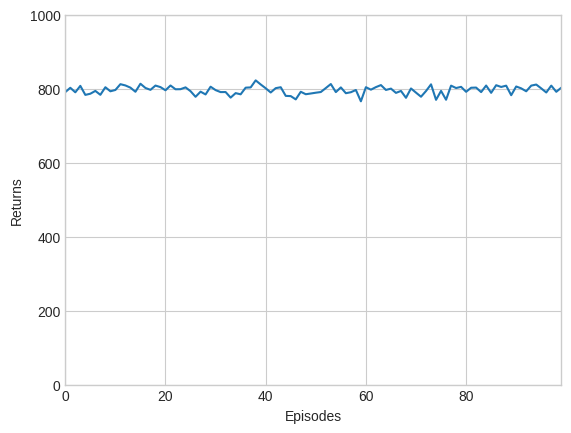

In [ ]:
iterations = range(0, num_iterations)
plt.plot(iterations, returns)

plt.ylabel('Returns')
plt.xlabel('Episodes')
plt.ylim([0, 1000])
plt.xlim([0, num_iterations-1])

plt.show()